In [ ]:
import numpy as np, torch, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine
from pathlib import Path
from config import TrainConfig, ModelConfig
from model_config import make_model
from inference import FloodInferenceEngine
from inference import build_subtitle, compute_class_pcts, save_result_as_tif, visualize_result_tif, _load_barangay_band_from_geojson, run_and_export

cfg  = TrainConfig()
mcfg = ModelConfig()
PATCH_SIZE = mcfg.patch_size

# ── Visual setup ──────────────────────────────────────────────────────────────
FLOOD_COLORS = {
     0: '#FFFFFF',
     1: '#C6DBEF',
     2: '#6BAED6',
     3: '#2171B5',
     4: '#08306B',
}
FLOOD_LABELS = {0: 'No Flood', 1: 'Light', 2: 'Moderate', 3: 'Heavy', 4: 'Extreme'}

conf_cmap  = 'RdYlGn'
flood_colors_rgba = [(1.0, 1.0, 1.0, 0.0), mcolors.to_rgba('#C6DBEF'), mcolors.to_rgba('#6BAED6'),  mcolors.to_rgba('#2171B5'),  mcolors.to_rgba('#08306B'), ]
flood_cmap = mcolors.ListedColormap(flood_colors_rgba)
flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)

legend_patches = [
    mpatches.Patch(facecolor='none', edgecolor='gray', linewidth=1.0, linestyle='--', label='Class 0 — No Flood'),
    *[
        mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray',
                       linewidth=0.5, label=f'Class {i} — {FLOOD_LABELS[i]}')
        for i in range(1, 5)
    ]
]

# ── Spatial data ──────────────────────────────────────────────────────────────
data                 = np.load(cfg.output_dir / 'spatial_data.npz')
X_full               = data['spatial']
manila_patch_indices = data['manila_patch_indices']
rain_min, rain_max   = float(data['rain_min'].item()), float(data['rain_max'].item())
N_H, N_W             = int(data['n_h'].item()),        int(data['n_w'].item())

# ── GeoTIFF transform ────────────────────────────────────────────────────────
with rasterio.open('COP-30m-GMM/greater_mm_bbox_dem_cop.tif') as src:
    t = src.transform
    dem_crs = src.crs
dem_transform = Affine(t.a * PATCH_SIZE, 0, t.c, 0, t.e * PATCH_SIZE, t.f)

# ── Model ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = make_model(ModelConfig()).to(device)

ckpt_files = sorted(cfg.output_dir.glob('fold_*/best_model.pt'))
best_ckpt = max(ckpt_files, key=lambda f: torch.load(f, map_location='cpu', weights_only=False).get('best_monitor', -np.inf))
print(best_ckpt)
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# ── Inference engine ──────────────────────────────────────────────────────────
engine = FloodInferenceEngine(
    model       = model,
    device      = device,
    rain_min    = rain_min,
    rain_max    = rain_max,
    X_spatial   = X_full,
    num_classes = cfg.num_classes,
    batch_size  = cfg.batch_size,
    manila_patch_indices = manila_patch_indices, 
)

print(f"Grid: {N_H}x{N_W}  |  Transform: {dem_transform.a:.0f}m pixels  |  CRS: {dem_crs}")


FLOOD INFERENCE ENGINE READY
  Device         : cpu
  Model          : ViT
  Spatial patches: 6,480 (Manila mask)
  Patch shape    : (4, 4, 3)
  Rain range     : [0.0000, 189.8531]
  Num classes    : 5
  Batch size     : 256
  Manila indices : 6,480 patches indexed

Grid: 306x281  |  Transform: 120m pixels  |  CRS: EPSG:3857


In [2]:
_GEOJSON_PATH  = 'manila_barangay_geojson.geojson'
_barangay_band = _load_barangay_band_from_geojson(_GEOJSON_PATH, dem_transform, dem_crs, N_H, N_W)

  Rasterizing 1011 barangays within DEM extent ...


c:\Users\mikos\Documents\thesis\th3-experiments\inference.py:514: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna() & gdf.geometry.is_valid]



Test 1/4
Predicting 6,480 patches (batch_size=256)...
  checkmark 1,280/6,480 patches
  checkmark 2,560/6,480 patches
  checkmark 3,840/6,480 patches
  checkmark 5,120/6,480 patches
  checkmark 6,400/6,480 patches
  checkmark 6,480/6,480 patches

PREDICTION SUMMARY
  Storm type     : triangular
  Depth          : 9 mm
  tpeak          : 0.5
  No warnings    : inputs within training range

  Confidence stats (Manila patches):
    Mean      : 0.7088
    Std       : 0.1978
    Min       : 0.3205
    Max       : 1.0000
    Uncertain : 28.3%  (conf < 0.5)

  Flood class distribution (Manila patches):
    No Flood    :   4,415 patches   68.1%  ##################################
    Light       :   1,806 patches   27.9%  #############
    Moderate    :     157 patches    2.4%  #
    Heavy       :      93 patches    1.4%  
    Extreme     :       9 patches    0.1%  


Test 2/4
Predicting 6,480 patches (batch_size=256)...
  checkmark 1,280/6,480 patches
  checkmark 2,560/6,480 patches
  checkm

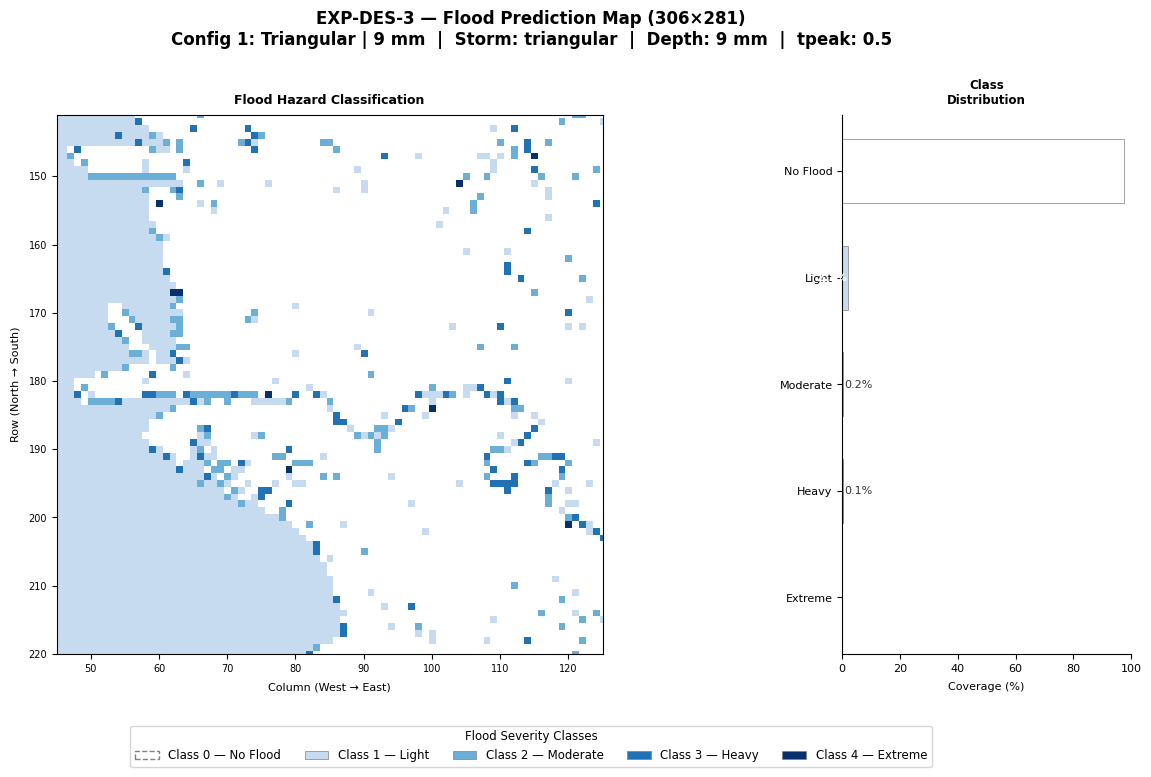

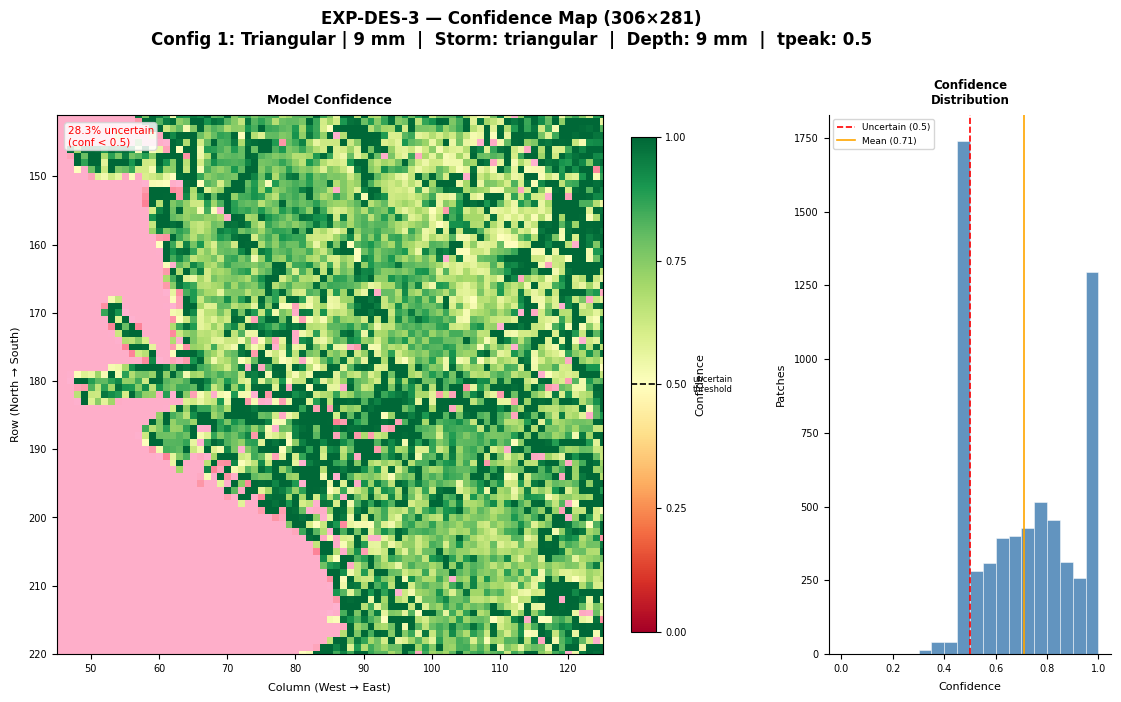

  ✓ GeoTIFF saved → checkpoints\web_config1_result.tif

GeoTIFF: checkpoints\web_config1_result.tif
  Band 1 : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2 : Confidence x1000 — divide by 1000 for 0.0-1.0
  Band 3 : Barangay PSGC Code (-1=outside Manila extent)
  Storm  : triangular  9mm  tpeak=0.5
  ✓ Visualization saved → checkpoints\web_config1_tif_bands.png


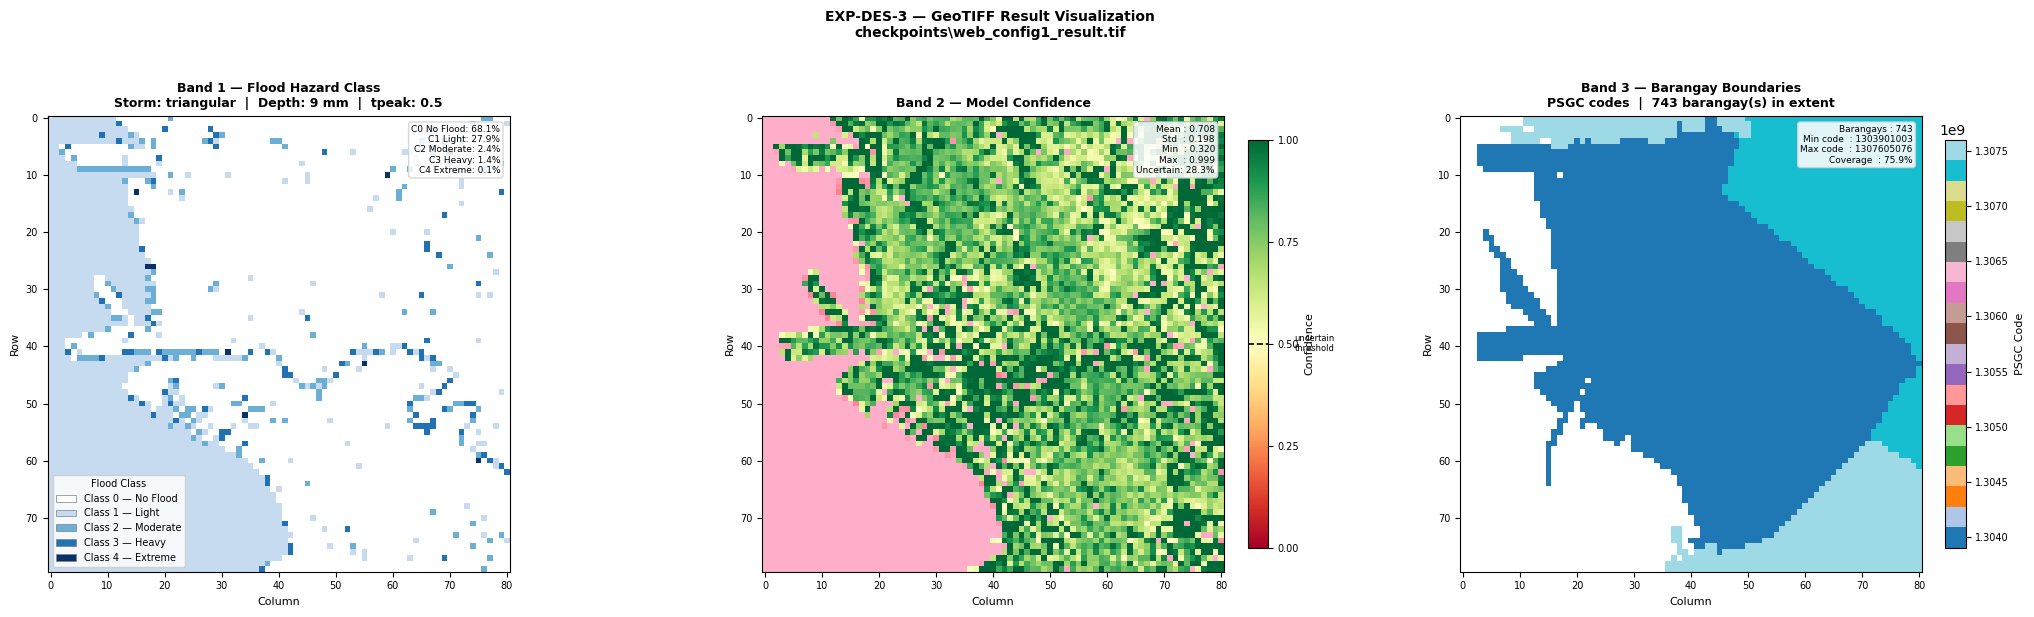

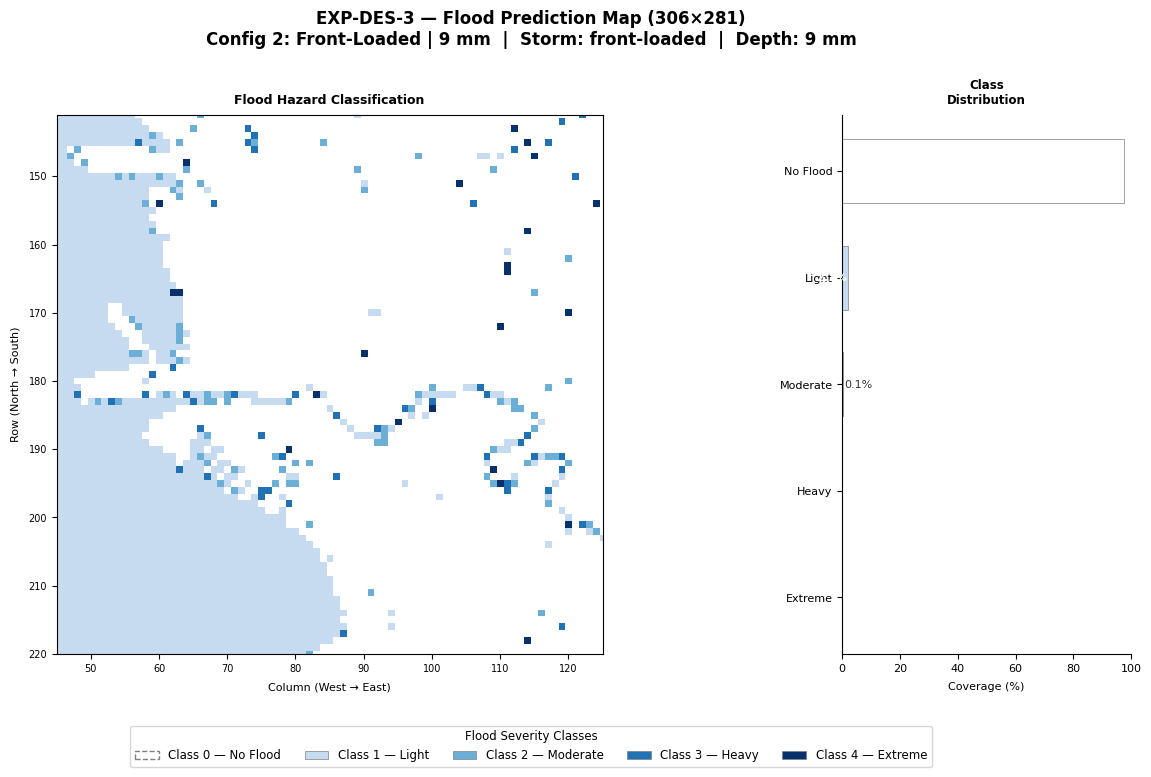

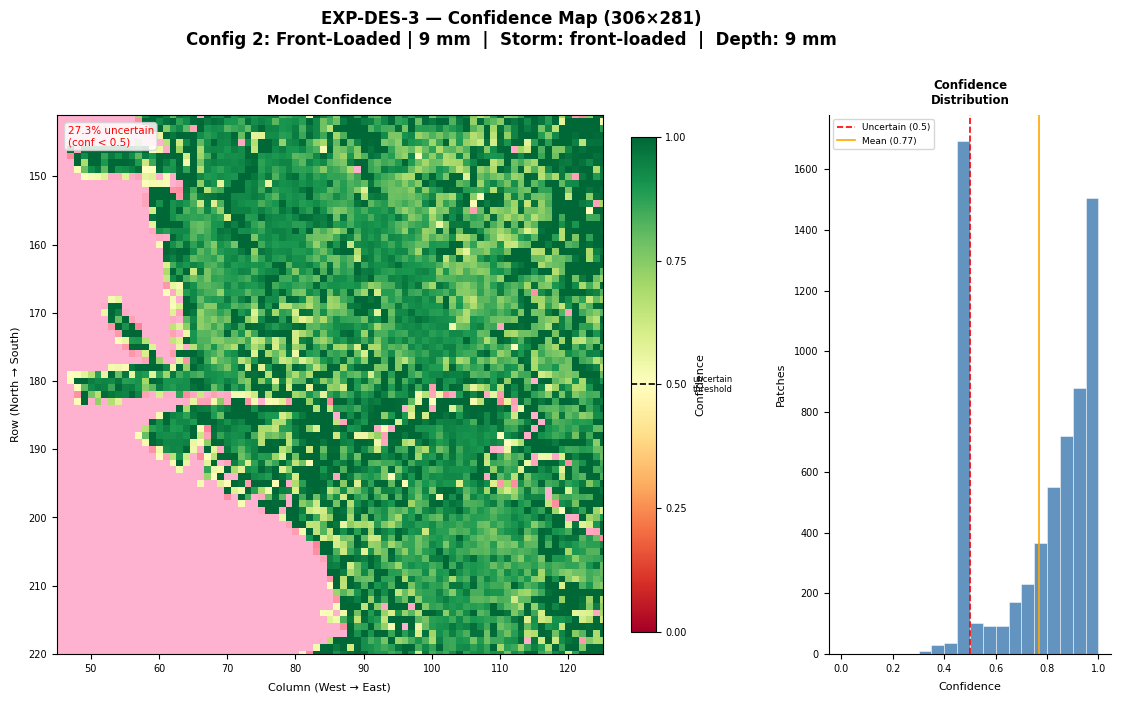

  ✓ GeoTIFF saved → checkpoints\web_config2_result.tif

GeoTIFF: checkpoints\web_config2_result.tif
  Band 1 : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2 : Confidence x1000 — divide by 1000 for 0.0-1.0
  Band 3 : Barangay PSGC Code (-1=outside Manila extent)
  Storm  : front-loaded  9mm  tpeak=None
  ✓ Visualization saved → checkpoints\web_config2_tif_bands.png


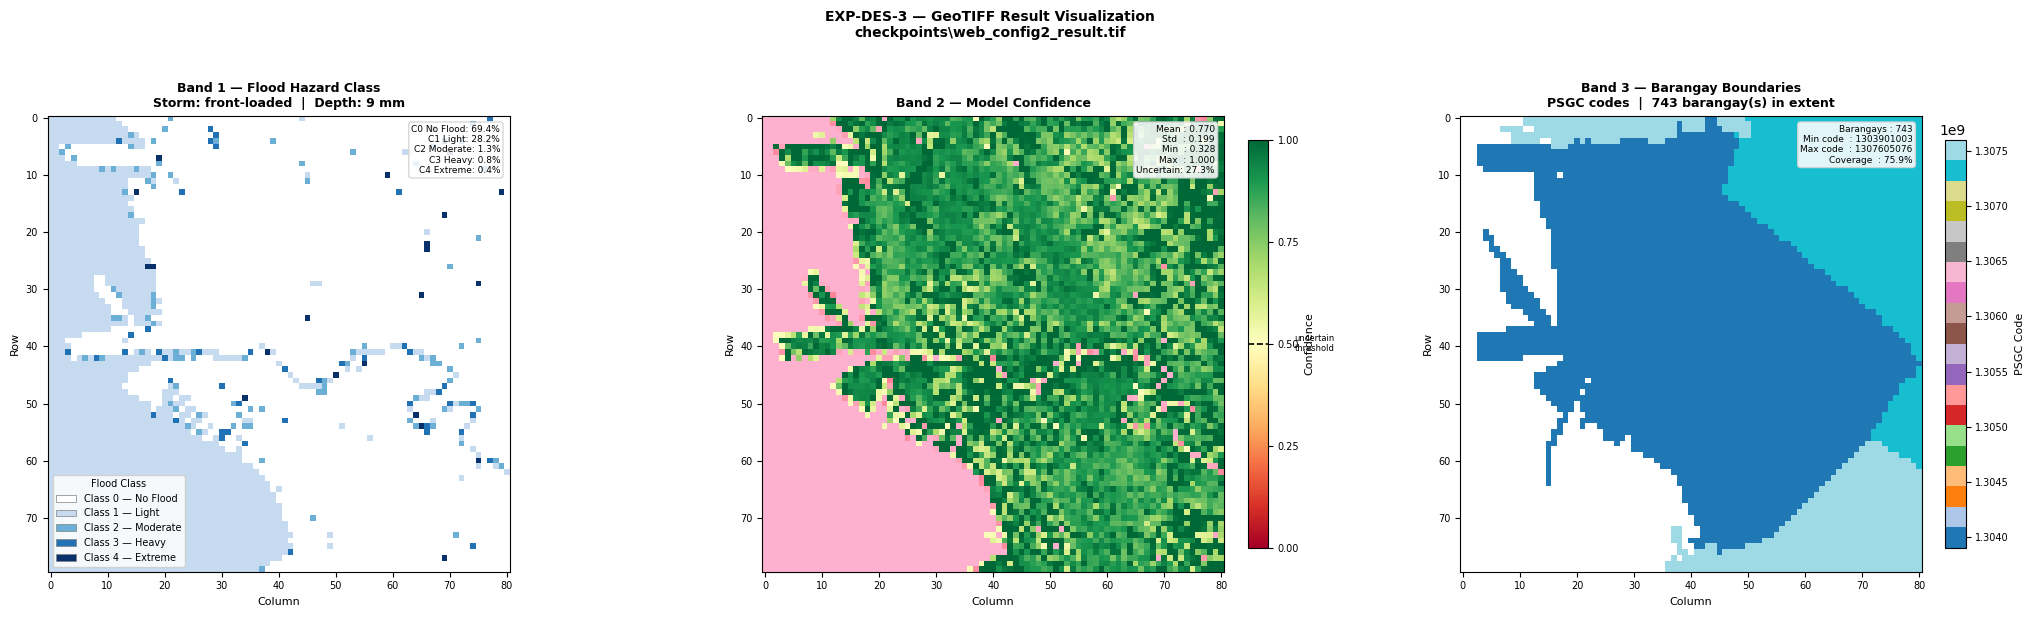

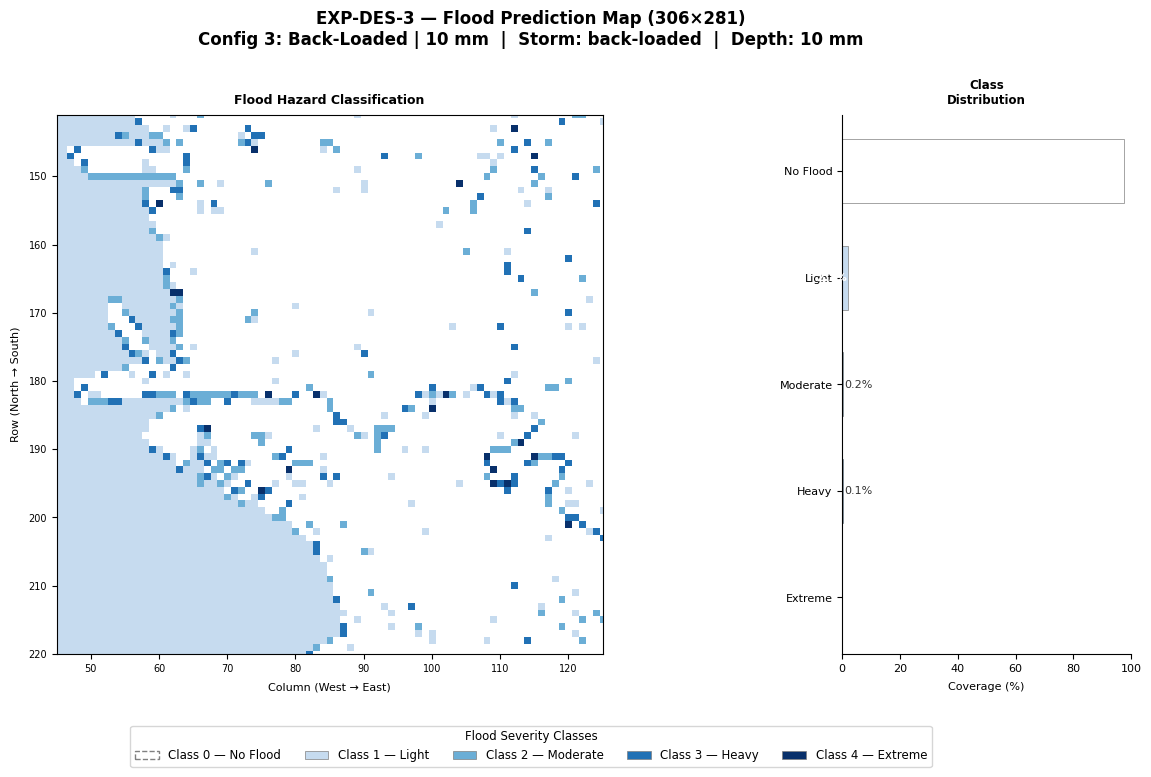

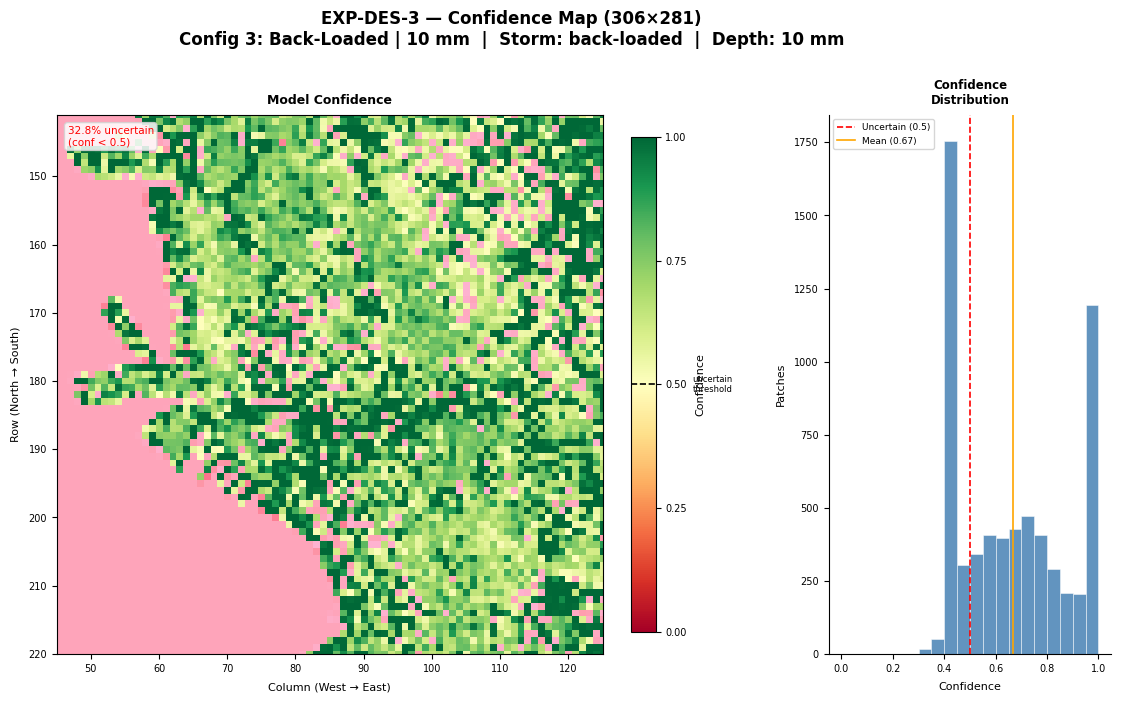

  ✓ GeoTIFF saved → checkpoints\web_config3_result.tif

GeoTIFF: checkpoints\web_config3_result.tif
  Band 1 : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2 : Confidence x1000 — divide by 1000 for 0.0-1.0
  Band 3 : Barangay PSGC Code (-1=outside Manila extent)
  Storm  : back-loaded  10mm  tpeak=None
  ✓ Visualization saved → checkpoints\web_config3_tif_bands.png


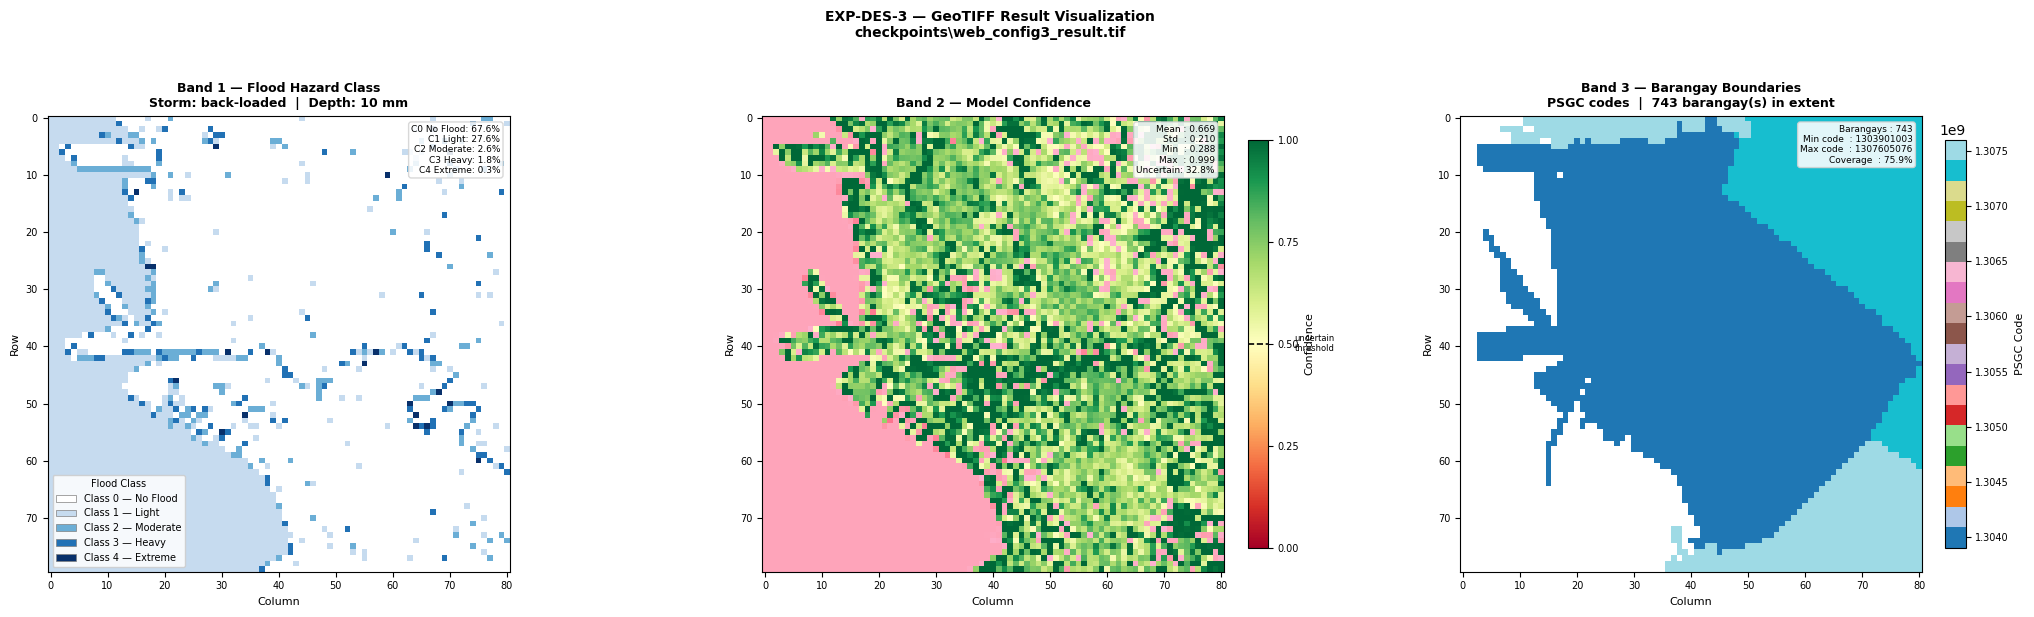

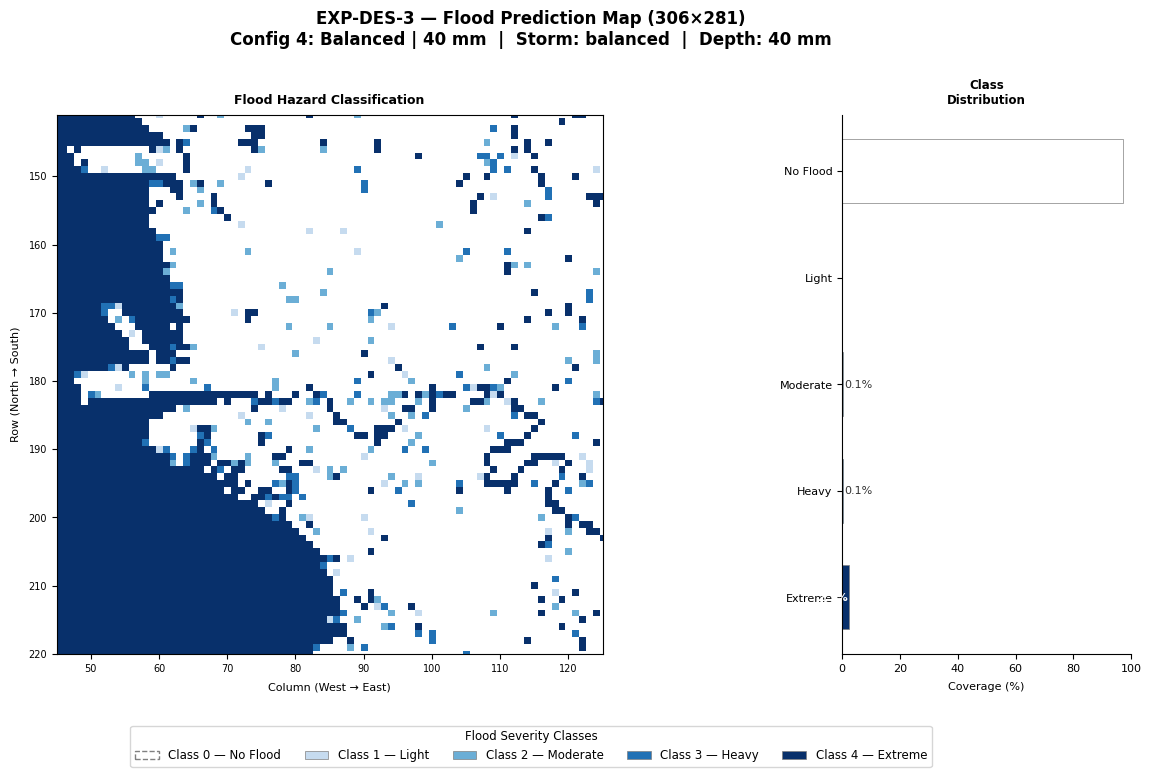

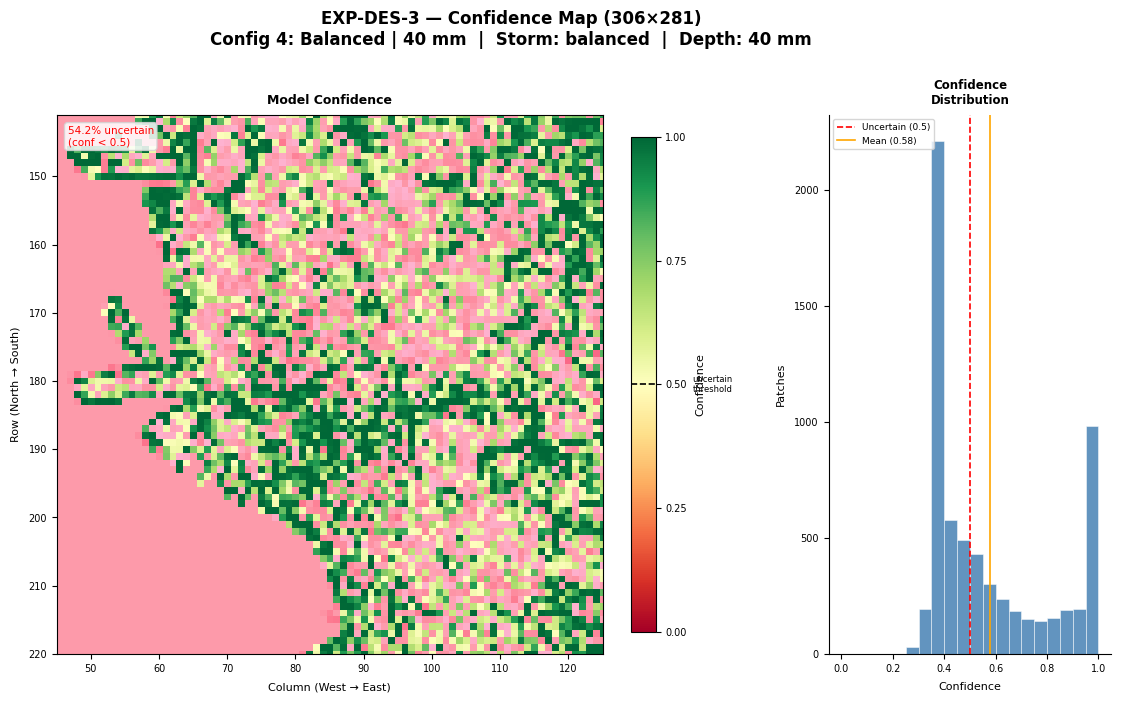

  ✓ GeoTIFF saved → checkpoints\web_config4_result.tif

GeoTIFF: checkpoints\web_config4_result.tif
  Band 1 : Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)
  Band 2 : Confidence x1000 — divide by 1000 for 0.0-1.0
  Band 3 : Barangay PSGC Code (-1=outside Manila extent)
  Storm  : balanced  40mm  tpeak=None
  ✓ Visualization saved → checkpoints\web_config4_tif_bands.png


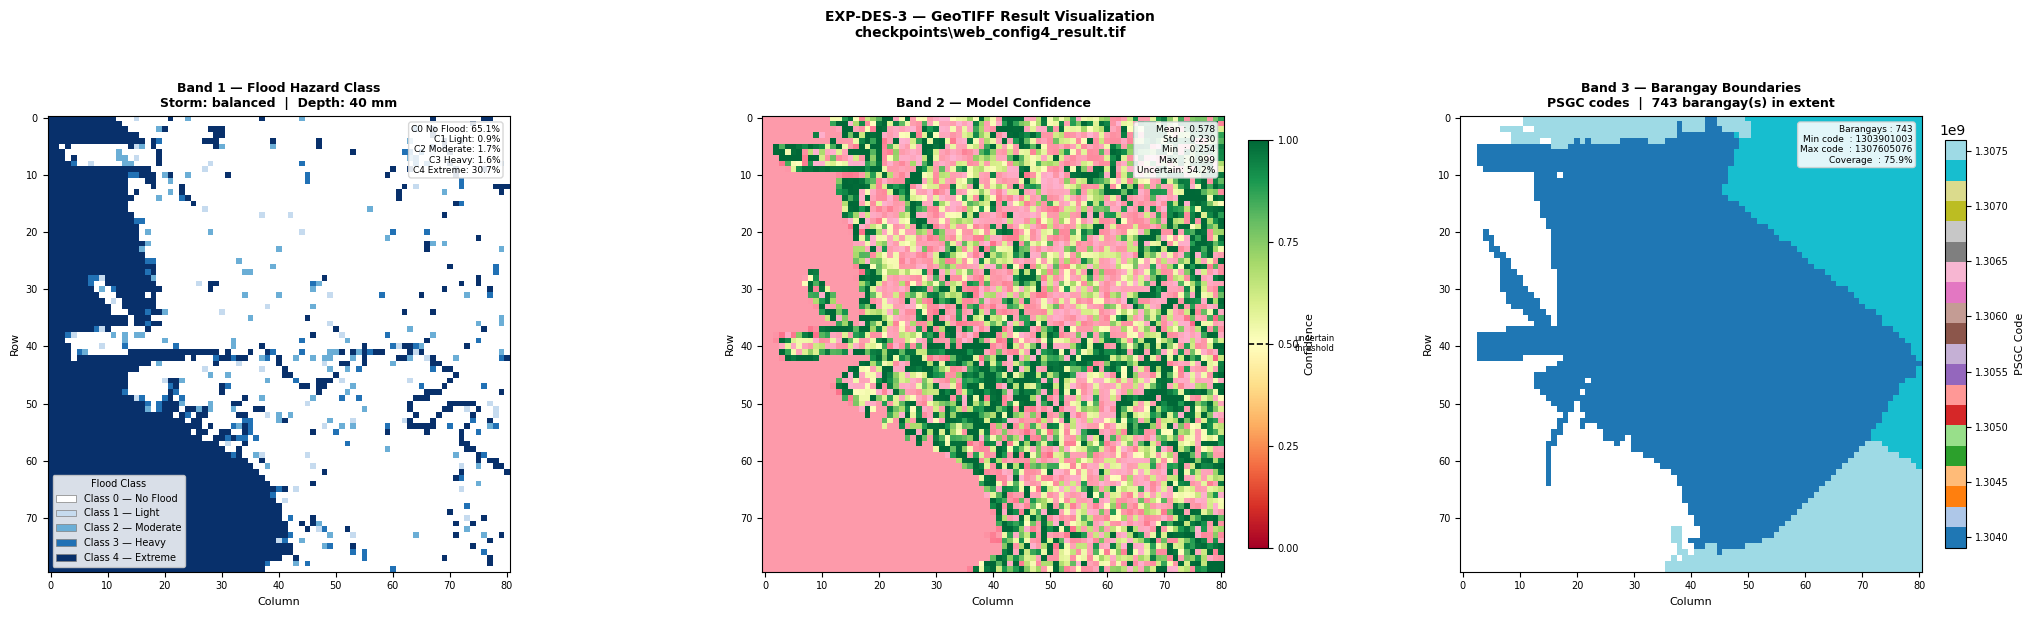


✓ All configurations processed.


In [ ]:
# ── Test configurations ───────────────────────────────────────────────────────
test_configs = [
    {'storm_type': 'triangular',   'depth_mm': 9,  'tpeak': 0.5},
    {'storm_type': 'front-loaded', 'depth_mm': 9,  'tpeak': None},
    {'storm_type': 'back-loaded',  'depth_mm': 10, 'tpeak': None},
    {'storm_type': 'balanced',     'depth_mm': 40, 'tpeak': None},
]

results = engine.predict_batch(test_configs, n_h=N_H, n_w=N_W)
run_and_export( results, test_configs, cfg.output_dir, N_H, N_W, manila_patch_indices, dem_transform, dem_crs, flood_cmap, flood_norm, legend_patches,_barangay_band,)